<a href="https://colab.research.google.com/github/banaria98/excel-intelligence-hub/blob/main/Final_project_group_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Team

**Canvas Group Name:**

* Group 9

**Team Members:**

| Name | UC Email |
|------|----------|
| Alina Banari | banariaa@mail.uc.edu |
| BJ Osibogun | osibogbj@ucmail.uc.edu |
| Chaypin Newman | newmacn@mail.uc.edu |
| Sumita Mahindra | mahinds@mail.uc.edu|

# Introduction

Regork is looking for opportunities to increase revenue and profitability by better understanding customer behavior during important holiday shopping periods. Thanksgiving and Christmas are two major seasonal shopping periods, but customers may not shop in the same way for each holiday. In particular, households with children may have different spending patterns, shopping frequency, basket sizes, and product preferences than households without children. Understanding these differences can help Regork make better decisions about inventory planning, product availability, holiday promotions, and customer targeting.

The business problem is that treating all households and holiday periods the same may lead to inaccurate assumptions about customer demand. This can result in overstocking lower-demand products, understocking products with higher demand, mistiming promotions, and misallocating store resources during important shopping periods. These issues can contribute to lost sales, excess inventory, supply-and-demand imbalances, and reduced customer satisfaction. The analysis is therefore relevant to Regork's Category Managers, Marketing Directors, and Store Operations leaders, who need to understand which customers are purchasing what products, how frequently they shop, and when demand changes around each holiday.

This project addresses the following main business question: **How can Regork use differences in holiday shopping behavior between households with and without children to improve inventory planning and targeted marketing during Thanksgiving and Christmas?** To answer this question, the analysis compares households with children and households without children during the three weeks leading up to each holiday and the week of the holiday. The analysis focuses on four main areas: spending per trip, shopping frequency, basket size, and product purchasing patterns. The analysis will also examine how these measures change from week to week and whether the patterns differ between Thanksgiving and Christmas.

The analysis uses the Complete Journey dataset through the `completejourney_py` Python package. Three datasets are central to the analysis: transactions, demographics, and products. The transactions data provides information about household purchases, including `household_id`, `basket_id`, `product_id`, `quantity`, `sales_value`, and `transaction_timestamp`. The demographics data allows households to be separated into households with children and households without children, while the products data provides department, product category, and product type information. These datasets will be joined using `household_id` and `product_id` so that purchasing behavior can be analyzed by household group, holiday period, and product category.

The analysis will first prepare and explore the data before comparing the two household groups across the Thanksgiving and Christmas periods. Spending per trip will be calculated by aggregating `sales_value` by shopping basket, shopping frequency will be measured using unique `basket_id` values, and basket composition will be examined using product quantities and distinct products purchased. Product and category purchasing patterns will then be analyzed to identify areas where demand increases or decreases around each holiday. Weekly comparisons will help identify when changes in shopping behavior occur as each holiday approaches.

Preliminary exploration supports the original project direction and shows that households with children and households without children do not behave identically during the holiday periods. Households with children had higher average spending per trip during both Thanksgiving and Christmas. Average spending was 35.56 for households with children compared with 30.61 for households without children during Thanksgiving, and 37.99 compared with $32.69 during Christmas. However, households without children made slightly more shopping trips during both holiday periods. These early findings suggest that spending and shopping frequency may provide different views of holiday customer behavior and support further investigation of basket composition and product purchasing patterns.

The goal of the final analysis is to use these differences to identify specific opportunities for Regork to improve holiday decision-making. The final recommendation will focus on how Regork can use household and holiday-specific purchasing patterns to better plan inventory and product availability and to develop more targeted holiday marketing. The recommendation will be based on the strongest findings from the analysis rather than assumptions about customer behavior, allowing Regork to make more informed decisions about where to focus resources during Thanksgiving and Christmas.

## Data Plan

### Datasets Required

List the Complete Journey tables your analysis requires and explain why each one is needed.

| Dataset | Why it's needed |
|---------|----------------|
| Transactions | `basket_id`, `household_id`, `product_id`, `quantity`, `sales_value`, and `transaction_timestamp` will allow us to measure spend, basket size, and *when* a purchase happened.  |
| Products | Mapping `product_id` into `department`, `product_category`, and `product_type`, so we can see which products spike.
| Demographics | Segments households "with children" vs. "without children" using `kids_count` |

### Key Joins

Describe how you will connect the tables (join keys, join types, and what you gain from each join).

Join `transactions` to `demographics` on `household_id` (inner join) to attach `kids_count` (and `income`) to every transaction, which lets us tag each household as `has_kids` or not. Also join `transactions` to `products` on `product_id` (inner join) to attach `department`, `product_category`, and `product_type`, which lets us see which categories are driving spend.

### Key Variables and Aggregations

List the columns and derived metrics central to your analysis. What are you measuring, and how will you calculate it?

| Variable | How it's derived | Why it matters |
|----------|-----------------|---------------|
| `has_kids` |`demographics['kids_count'] != '0'` | Groups households into two categories: those with no children (0) and those with one or more children, based on kid_count|
| `holiday` | Filtering `transaction_timestamp` against the calendar date range for each holiday (3 weeks before, through the week of) | Allows us to compare the twwo holidays. |
| `spend_per_trip` | Sum of `sales_value` per `basket_id` | Tells us how much a household spends per trip. |
| `basket_size` | Count of distinct`product_id` values per `basket_id` | Tells us how many different products are included in a shopping trip and whether households purchase larger or smaller baskets around each holiday. |
| `trip_frequency` | Count of unique `basket_id` values per `household_id` | Tells us how often a household visits the store around the holidays.
| `week` | From transaction table | Tells us spending and frequency shifts week to week |

# Packages

In [ ]:
!pip install completejourney-py -q

# Supress non-critical warnings
import warnings
warnings.filterwarnings("ignore")

# Used for data manipulation, joins, and aggregation
import numpy as np
import pandas as pd

# Used for creating visualizations
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from completejourney_py import get_data

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:,.2f}".format)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.6/31.6 MB 57.8 MB/s eta 0:00:00


# Data Preparation

In [ ]:
# Import Data
cj_data = get_data()

transactions = cj_data['transactions']
demographics = cj_data['demographics']
products     = cj_data['products']

print("transactions:", transactions.shape)
print("demographics:", demographics.shape)
print("products:    ", products.shape)

transactions: (1469307, 11)
demographics: (801, 8)
products:     (92331, 7)


In [ ]:
# Inspect
for name, df in [("transactions", transactions), ("demographics", demographics), ("products", products)]:
    print(f"===== {name} =====")
    print(df.dtypes.to_string())
    print("\nMissing values:")
    print(df.isna().sum()[df.isna().sum() > 0].to_string() or "none")
    print("Duplicate rows:", df.duplicated().sum(), "\n")

===== transactions =====
household_id                      int64
store_id                          int64
basket_id                         int64
product_id                        int64
quantity                          int64
sales_value                     float64
retail_disc                     float64
coupon_disc                     float64
coupon_match_disc               float64
week                              int64
transaction_timestamp    datetime64[ns]

Missing values:
Series([], )
Duplicate rows: 0 

===== demographics =====
household_id       int64
age               object
income            object
home_ownership    object
marital_status    object
household_size    object
household_comp    object
kids_count        object

Missing values:
home_ownership    233
marital_status    137
Duplicate rows: 0 

===== products =====
product_id           int64
manufacturer_id      int64
department          object
brand               object
product_category    object
product_type        obj

In [ ]:
# Date range, and household coverage between tables
print("Transaction dates:", transactions['transaction_timestamp'].min(), "->", transactions['transaction_timestamp'].max())
print("Unique households in transactions:", transactions['household_id'].nunique())
print("Households with demographics:     ", demographics['household_id'].nunique())
print(f"Share of transaction rows from households that have demographics: "
      f"{transactions['household_id'].isin(demographics['household_id']).mean():.1%}")
print(f"Share of transaction rows whose product_id exists in products:     "
      f"{transactions['product_id'].isin(products['product_id']).mean():.2%}")
print("\nkids_count values:")
print(demographics['kids_count'].value_counts(dropna=False).to_string())

Transaction dates: 2017-01-01 11:53:26 -> 2018-01-01 04:01:20
Unique households in transactions: 2469
Households with demographics:      801
Share of transaction rows from households that have demographics: 56.4%
Share of transaction rows whose product_id exists in products:     99.67%

kids_count values:
kids_count
0     513
1     159
3+     69
2      60


In [ ]:
# Questionable values in transactions
print("Rows with quantity <= 0:   ", (transactions['quantity'] <= 0).sum())
print("Rows with sales_value <= 0:", (transactions['sales_value'] <= 0).sum())
print("\nquantity percentiles:")
print(transactions['quantity'].quantile([.5, .9, .99, .999]).to_string())

# Extreme quantities
extreme = transactions[transactions['quantity'] > 1000].merge(products, on='product_id', how='left')
print("\nProducts behind quantity > 1000:")
print(extreme.groupby(['department', 'product_type']).size().sort_values(ascending=False).head())

Rows with quantity <= 0:    8869
Rows with sales_value <= 0: 11226

quantity percentiles:
0.50        1.00
0.90        2.00
0.99       12.00
1.00   17,147.94

Products behind quantity > 1000:
department     product_type         
FUEL           GASOLINE-REG UNLEADED    11818
MISCELLANEOUS  GASOLINE-REG UNLEADED     1676
dtype: int64


Throughout this inspection, we discovered that there are no duplicate rows and no missing values in transactions. kids_count is stored as text and also has no missing values. Additionally, only about 56% of transaction rows belong to households with demographic data, and because our business question relies on kids_count, we will only be using 801 of the 2,469 households.

In [ ]:
# Clean Data
n0 = len(transactions)
# Keep real purchases only
txn = transactions[(transactions['quantity'] > 0) & (transactions['sales_value'] > 0)].copy()
print(f"Dropped non-purchase rows (qty<=0 or sales<=0): {n0 - len(txn):,}")

# Drop FUEL
fuel_ids = products.loc[(products['department'] == 'FUEL') |
                        products['product_type'].str.contains('GASOLINE', na=False), 'product_id']
n1 = len(txn)
txn = txn[~txn['product_id'].isin(fuel_ids)]
print(f"Dropped FUEL / gasoline rows: {n1 - len(txn):,}")
print("Max quantity remaining:", txn['quantity'].max())

# Define has_kids
demographics = demographics.copy()
demographics['has_kids'] = np.where(demographics['kids_count'] == '0', 'No kids', 'With kids')
print("\n", demographics['has_kids'].value_counts().to_string())

# Standardize text columns
for col in ['department', 'product_category', 'product_type']:
    products[col] = products[col].str.strip().str.upper()

print(f"\nRows remaining: {len(txn):,} of {n0:,}")

Dropped non-purchase rows (qty<=0 or sales<=0): 11,275
Dropped FUEL / gasoline rows: 14,697
Max quantity remaining: 144

 has_kids
No kids      513
With kids    288

Rows remaining: 1,443,335 of 1,469,307


In [ ]:
# Define holiday windows -> 3 weeks before the holiday through the 6 days after it occurred
holidays = {
    'Thanksgiving': pd.Timestamp(2017, 11, 23),
    'Christmas':    pd.Timestamp(2017, 12, 25),
}
period_labels = {0: '3 wks before', 1: '2 wks before', 2: '1 wk before', 3: 'Holiday week'}

txn['date'] = txn['transaction_timestamp'].dt.normalize()

windows = []
for name, day in holidays.items():
    start, end = day - pd.Timedelta(weeks=3), day + pd.Timedelta(days=6)
    w = txn[(txn['date'] >= start) & (txn['date'] <= end)].copy()
    w['holiday'] = name
    w['window_week'] = (w['date'] - start).dt.days // 7
    w['window_label'] = w['window_week'].map(period_labels)
    windows.append(w)
    print(f"{name}: {start.date()} -> {end.date()} | {len(w):,} rows")

holiday_txn = pd.concat(windows, ignore_index=True)
assert not set(holiday_txn.groupby('holiday')['date'].max()) - {pd.Timestamp(2017,11,29), pd.Timestamp(2017,12,31)}


Thanksgiving: 2017-11-02 -> 2017-11-29 | 112,985 rows
Christmas: 2017-12-04 -> 2017-12-31 | 112,720 rows


In [ ]:
# Join Data
n_before = len(holiday_txn)

step1 = holiday_txn.merge(
    demographics[['household_id', 'has_kids', 'kids_count', 'income']],
    on='household_id', how='inner', validate='m:1')
print(f"After demographics join: {len(step1):,} rows  (dropped {n_before - len(step1):,} from households with no demographics)")

holiday_df = step1.merge(
    products[['product_id', 'department', 'product_category', 'product_type']],
    on='product_id', how='inner', validate='m:1')
print(f"After products join:     {len(holiday_df):,} rows  (dropped {len(step1) - len(holiday_df):,} with no product match)")

print("\nHouseholds per group in the final data:")
print(holiday_df.groupby('has_kids')['household_id'].nunique().to_string())
print("\nRows by holiday x group:")
print(holiday_df.groupby(['holiday', 'has_kids']).size().unstack().to_string())

After demographics join: 126,423 rows  (dropped 99,282 from households with no demographics)
After products join:     126,419 rows  (dropped 4 with no product match)

Households per group in the final data:
has_kids
No kids      505
With kids    286

Rows by holiday x group:
has_kids      No kids  With kids
holiday                         
Christmas       39429      24590
Thanksgiving    38301      24099


In [ ]:
# One row per shopping trip (basket)
basket_df = (holiday_df
    .groupby(['holiday', 'window_week', 'window_label', 'has_kids', 'household_id', 'basket_id'], as_index=False)
    .agg(spend_per_trip=('sales_value', 'sum'),
         basket_size=('product_id', 'nunique'),
         total_items=('quantity', 'sum')))

# One row per household x holiday x week: trip frequency
freq_df = (basket_df
    .groupby(['holiday', 'window_week', 'window_label', 'has_kids', 'household_id'], as_index=False)
    .agg(trips=('basket_id', 'nunique'),
         weekly_spend=('spend_per_trip', 'sum')))

print("basket_df:", basket_df.shape, "| freq_df:", freq_df.shape)
display(basket_df.head())

basket_df: (11252, 9) | freq_df: (4900, 7)


,holiday,window_week,window_label,has_kids,household_id,basket_id,spend_per_trip,basket_size,total_items
0,Christmas,0,3 wks before,No kids,1,41008476635,8.14,2,2
1,Christmas,0,3 wks before,No kids,7,41026465249,20.50,14,15
2,Christmas,0,3 wks before,No kids,16,41125050772,9.48,4,7
3,Christmas,0,3 wks before,No kids,17,41008691310,45.61,13,39
4,Christmas,0,3 wks before,No kids,17,41124022002,41.45,6,21


## Cleaning Data Decisions Summary
1. Dropped rows with quantity <= 0 or sales_value <= 0 to drop all rows that are not purchases.
2. Excluded gasoline (FUEL) because its values inflate item counts and it is not a holiday-shopping category.
3. has_kids = 'No kids' if kids_count == '0', otherwise 'With kids'
4. Inner join to demographics and inner join to products
5. Holiday windows = 3 weeks before through 6 days after each holiday
6. basket_size = distinct product_id per basket_id; total_items is kept separately
7. Trip frequency only counts households with at least one trip in the period

## Exploratory Data Analysis

1. Do households with kids spend more per trip?
2. Do households with kids shop more often?
3. When does spending actually ramp up before each holiday?
4. Is the higher spend from more items per basket, or pricier items?
5. Which departments does each group prioritize?

1. Households with kids spend more per trip than households without kids, at both holidays. They spent around \$6.00 more during Christmas and \$5.50 more during Thanksgiving.

mean_spend  median_spend  n_trips
holiday      has_kids                                    
Christmas    No kids         33.60         18.74     3623
             With kids       39.60         20.98     1960
Thanksgiving No kids         31.13         17.77     3688
             With kids       36.63         19.07     1981

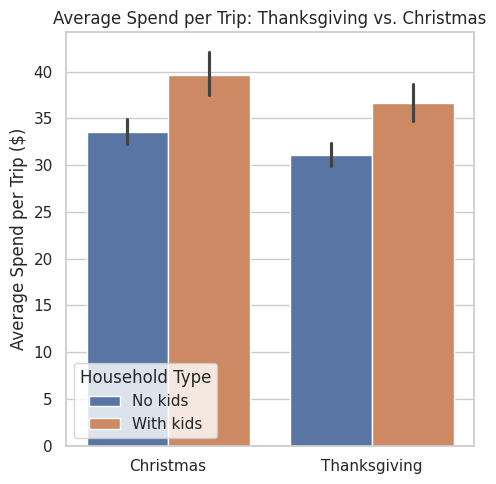

In [ ]:
# Mean and median spend per trip, by holiday and household group

spend_summary = (basket_df
    .groupby(['holiday', 'has_kids'])['spend_per_trip']
    .agg(mean_spend='mean', median_spend='median', n_trips='count')
    .round(2))
display(spend_summary)

plt.figure(figsize=(5, 5))
sns.barplot(data=basket_df, x='holiday', y='spend_per_trip', hue='has_kids', estimator='mean')
plt.title('Average Spend per Trip: Thanksgiving vs. Christmas')
plt.ylabel('Average Spend per Trip ($)')
plt.xlabel('')
plt.legend(title='Household Type')
plt.tight_layout()
plt.show()

2. Households without kids make slightly more trips than households with kids during both holiday windows. Households with kids appear to make fewer but bigger trips, while households without kids make more frequent but smaller trips.

avg_trips  n_households
holiday      has_kids                          
Christmas    No kids         2.33           491
             With kids       2.24           282
Thanksgiving No kids         2.32           496
             With kids       2.26           279

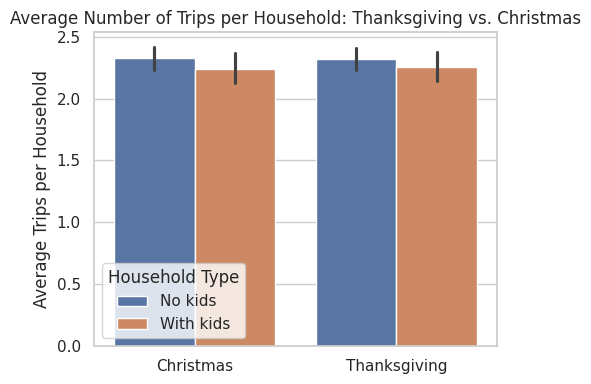

In [ ]:
# Average number of trips per household, by holiday and household group
freq_summary = (freq_df
    .groupby(['holiday', 'has_kids'])
    .agg(avg_trips=('trips', 'mean'), n_households=('household_id', 'nunique'))
    .round(2))
display(freq_summary)

plt.figure(figsize=(5, 4))
sns.barplot(data=freq_df, x='holiday', y='trips', hue='has_kids', estimator='mean', )
plt.title('Average Number of Trips per Household: Thanksgiving vs. Christmas')
plt.ylabel('Average Trips per Household')
plt.xlabel('')
plt.legend(title='Household Type')
plt.tight_layout()
plt.show()

3. Spending for both demographics is consistent until 1 week before where we see the biggest spike leading into the holiday week. Households with kids already show an increase in spend 2-3 weeks out for both holidays but a much more significant 31% increase compared to a 12% increase of households wihoiut kids. This suggests that Ads targeting household without kids should start much earlier and more funds should be allocated towards that demographic.

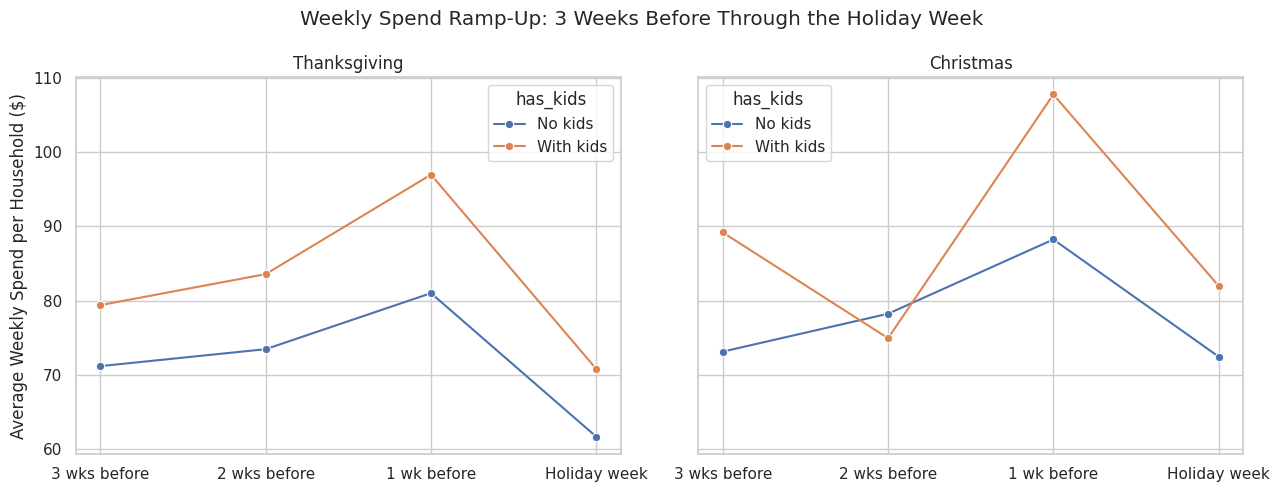

In [ ]:
# Average weekly household spend, by date range, holiday, and household group
week_order = [period_labels[i] for i in sorted(period_labels)]

weekly_summary = (freq_df
    .groupby(['holiday', 'window_label', 'has_kids'])['weekly_spend']
    .mean()
    .reset_index())
weekly_summary['window_label'] = pd.Categorical(weekly_summary['window_label'], categories=week_order, ordered=True)
weekly_summary = weekly_summary.sort_values('window_label')

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, holiday_name in zip(axes, ['Thanksgiving', 'Christmas']):
    subset = weekly_summary[weekly_summary['holiday'] == holiday_name]
    sns.lineplot(data=subset, x='window_label', y='weekly_spend', hue='has_kids', marker='o', ax=ax)
    ax.set_title(holiday_name)
    ax.set_xlabel('')
    ax.set_ylabel('Average Weekly Spend per Household ($)' if holiday_name == 'Thanksgiving' else '')

plt.suptitle('Weekly Spend Ramp-Up: 3 Weeks Before Through the Holiday Week')
plt.tight_layout()
plt.show()

4. Households with kids buy more distinct products per trip than households without kids with a mean of 12.55 vs. 10.88 items at Christmas and 12.17 vs. 10.39 at Thanksgiving, even though both groups share the exact same median of 6. This confirms that households with kids aren't just buying pricier items, they're filling bigger baskets with more things.

mean_size  median_size
holiday      has_kids                         
Christmas    No kids        10.88         6.00
             With kids      12.55         6.00
Thanksgiving No kids        10.39         6.00
             With kids      12.17         6.00

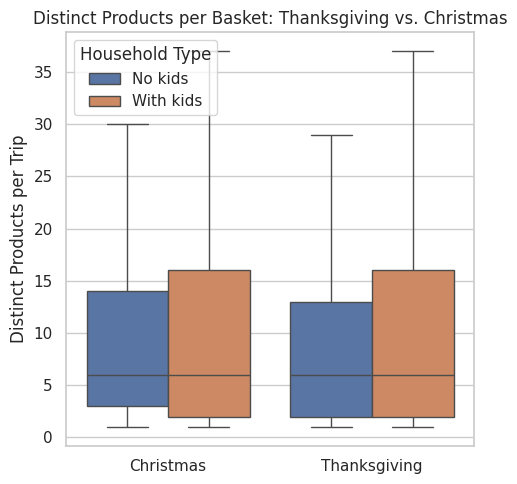

In [ ]:
# Distinct products per basket (basket_size), by holiday and household group
basket_size_summary = (basket_df
    .groupby(['holiday', 'has_kids'])['basket_size']
    .agg(mean_size='mean', median_size='median')
    .round(2))
display(basket_size_summary)

plt.figure(figsize=(5, 5))
sns.boxplot(data=basket_df, x='holiday', y='basket_size', hue='has_kids', showfliers=False)
plt.title('Distinct Products per Basket: Thanksgiving vs. Christmas')
plt.ylabel('Distinct Products per Trip')
plt.xlabel('')
plt.legend(title='Household Type')
plt.tight_layout()
plt.show()

Grocery department had the most total spend for both groups and both holidays, roughly three to 4 times more than the next category. Also the relative ranking of departments is identical across all four segments, meaning neither household type nor holiday shifts which departments should be prioritized.

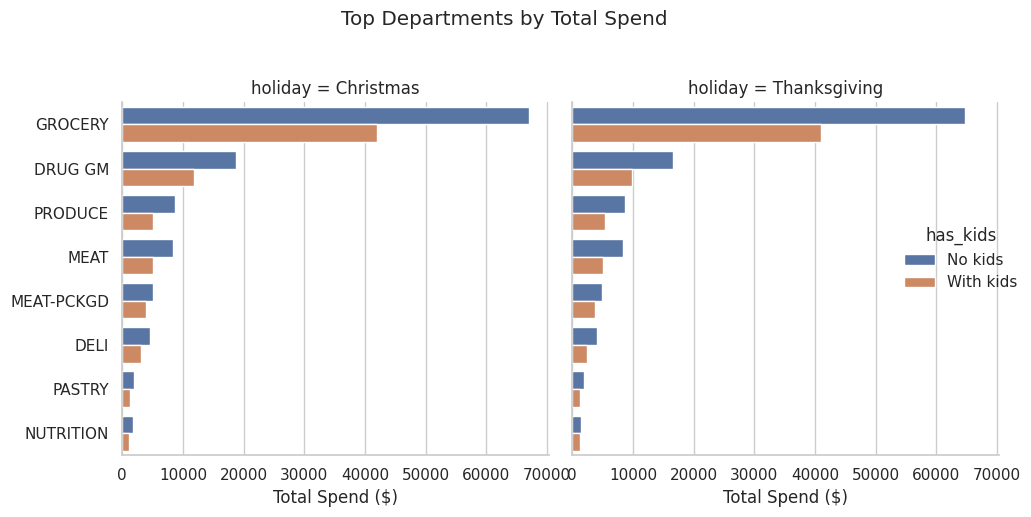

In [ ]:
# Total spend by departments across both holidays, with the highest overall
top_departments = (holiday_df.groupby('department')['sales_value'].sum()
                    .sort_values(ascending=False).head(8).index)

dept_summary = (holiday_df[holiday_df['department'].isin(top_departments)]
    .groupby(['holiday', 'has_kids', 'department'])['sales_value']
    .sum()
    .reset_index())

g = sns.catplot(data=dept_summary, kind='bar', x='sales_value', y='department',
                 hue='has_kids', col='holiday', height=5, aspect=0.9,
                 order=top_departments)
g.set_axis_labels('Total Spend ($)', '')
g.fig.suptitle('Top Departments by Total Spend', y=1.03)
plt.tight_layout()
plt.show()